# Markov Chain Monte Carlo

Besides Variational Inference, another possible way of approximating distributions is through Monte Carlo methods. These methods use sampling to approximate a distribution $p$.

In [2]:
%load_ext autoreload
%autoreload 2

import math
import random

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

mpl.rc_file_defaults()

In [3]:
mean = 4.0
sigma = 2.0

for num_samples in [10, 100, 1000, 10_000]:
    s = 0
    for i in range(num_samples):
        s += random.gauss(mu=mean, sigma=sigma)
    print(f"Approximate mean: {s / num_samples}")

Approximate mean: 3.215948804217464
Approximate mean: 3.812285320441147
Approximate mean: 3.9859230408583746
Approximate mean: 4.0060829499229795


The idea is that if we can draw samples from some distribution, then by the law of large numbers, we can approximate the true mean using these samples.

In [4]:
def q(x_input):
    return (
            0.3 * math.exp(-((x_input + 2) ** 2) / 2) +
            0.7 * math.exp(-((x_input - 2) ** 2) / 2)
    ) / math.sqrt(2 * math.pi)

In [5]:
x = 1.0
sigma = 1.0

x_list = []
for _ in range(100_000):
    x_prime = random.gauss(mu=x, sigma=sigma)
    alpha = min(1.0, float(q(x_prime) / q(x)))

    prob = random.random()
    if alpha >= prob:
        x = x_prime
    x_list.append(x)

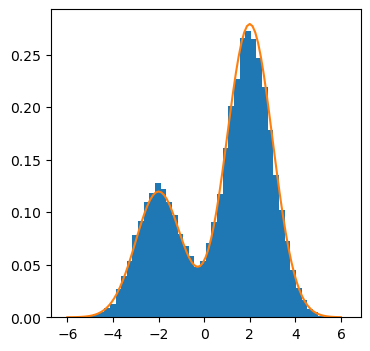

In [6]:
x = np.linspace(-6, 6, num=100)
y = np.array([q(x_i) for x_i in x])

fig, ax = plt.subplots(figsize=(4, 4))

ax.hist(x_list, bins=50, density=True)
ax.plot(x, y)

plt.show()

In [15]:
x_true = -np.ones((50, 50))
x_true[15:35, 15:35] = 1

x_observed = x_true.copy().ravel()
samples = np.random.choice(50 * 50, 300, replace=False)

mask_zero = x_observed[samples] == -1
mask_one = x_observed[samples] == 1
x_observed[samples] = np.where(mask_zero, 1, x_observed[samples])
x_observed[samples] = np.where(mask_one, -1, x_observed[samples])
x_observed = x_observed.reshape((50, 50))

In [27]:
def ising_model(
    o: float,
    ext: np.ndarray,
    s: float,
    h: float = 0.1,
    beta: float = 1.0,
    lam: float = 1.0
):
    return np.exp(s * (h + beta * ext.sum() + lam * o))

In [28]:
x_restored = np.zeros((50, 50))
for i in range(50):
    for j in range(50):
        left = min(0, i - 1)
        right = max(50, i + 1)
        top = min(0, j - 1)
        bottom = max(50, j + 1)
        prob_pos = ising_model(
            x_observed[i, j],
            x_observed[left:right, top:bottom],
            s=1.0
        )
        prob_neg = ising_model(
            x_observed[i, j],
            x_observed[left:right, top:bottom],
            s=-1.0
        )
        print(prob_pos, prob_neg)
        if prob > 0.5:
            x_restored[i, j] = 1
        else:
            x_restored[i, j] = -1

0.14956861922263506 6.6858944422792685
1.7272519440314302e-18 5.789543346328422e+17
1.7272519440314302e-18 5.789543346328422e+17
1.276276151143526e-17 7.835294885860035e+16
1.7272519440314302e-18 5.789543346328422e+17
1.7272519440314302e-18 5.789543346328422e+17
1.7272519440314302e-18 5.789543346328422e+17
1.7272519440314302e-18 5.789543346328422e+17
1.7272519440314302e-18 5.789543346328422e+17
1.7272519440314302e-18 5.789543346328422e+17
1.7272519440314302e-18 5.789543346328422e+17
1.7272519440314302e-18 5.789543346328422e+17
1.7272519440314302e-18 5.789543346328422e+17
1.7272519440314302e-18 5.789543346328422e+17
1.7272519440314302e-18 5.789543346328422e+17
1.7272519440314302e-18 5.789543346328422e+17
1.7272519440314302e-18 5.789543346328422e+17
1.7272519440314302e-18 5.789543346328422e+17
1.7272519440314302e-18 5.789543346328422e+17
1.7272519440314302e-18 5.789543346328422e+17
1.7272519440314302e-18 5.789543346328422e+17
1.7272519440314302e-18 5.789543346328422e+17
1.727251944031430

/tmp/ipykernel_8412/315292814.py:9: RuntimeWarning: overflow encountered in exp
  return np.exp(s * (h + beta * ext.sum() + lam * o))


In [18]:
x_restored

array([[ 1.,  1., -1., ..., -1., -1., -1.],
       [ 1., -1., -1., ..., -1., -1., -1.],
       [-1., -1., -1., ..., -1., -1., -1.],
       ...,
       [-1., -1., -1., ..., -1., -1., -1.],
       [-1., -1., -1., ..., -1., -1., -1.],
       [-1., -1., -1., ..., -1., -1., -1.]], shape=(50, 50))

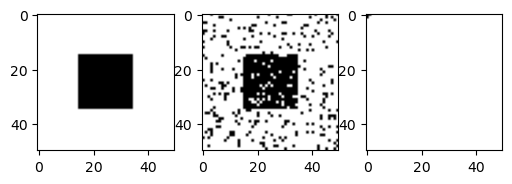

In [19]:
fig, ax = plt.subplots(1, 3, figsize=(6, 4))

ax[0].imshow(x_true, cmap=ListedColormap(["white", "black"]))
ax[1].imshow(x_observed, cmap=ListedColormap(["white", "black"]))
ax[2].imshow(x_restored, cmap=ListedColormap(["white", "black"]))

plt.show()